# 🧠 SONATA Edge Editor — Demo

This notebook demonstrates the `SonataEdgeEditor` context manager.

**Workflow:**
1. Set a SONATA edge HDF5 file to INPUT_H5
2. Explore Edge Properties
3. Set an edge type id to edit 
4. Set what fraction of edges to randomly remove
5. Run the replacement code with SonataEdgeEditor
6. Compare before/after histograms

In [1]:
import polars as pl
import numpy as np
import tempfile
import os
import h5py

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from airavata_cerebrum.sonata.edge import SonataEdgeEditor, EditConfig, IndexType

#

## Step 1 — Select Input Edges File

In [2]:
INPUT_H5 = "model_prior/v1_test/network_v1/left_local_edges.edge_types_120.sorted.h5"

## Step 2 — Inspect Edge File Properties

In [3]:
et_cfg = EditConfig(
        edge_type_index_group = "edge_type_to_index",
        type_to_range_dataset = "node_id_to_range",
        range_to_edge_dataset = "range_to_edge_id",
)

with SonataEdgeEditor(INPUT_H5, edge_type_index_cfg=et_cfg) as _ed:
    _idx   = _ed.has_indices()
    _pop   = _ed.population

    # read full edge table to get type counts
    import h5py as _h5py
    with _h5py.File(INPUT_H5, "r") as _f:
        _grp = _f[f"edges/{_pop}"]
        import numpy as _np
        _etypes = _grp["edge_type_id"][:]

counts_df = (
    pl.DataFrame({"edge_type_id": _etypes})
    .group_by("edge_type_id")
    .agg(pl.len().alias("count"))
    .sort("edge_type_id")
)
_type_ids = counts_df["edge_type_id"].to_list()
# expose for downstream cells
file_population = _pop
file_type_ids   = _type_ids

pl.DataFrame(
    {
        "Edge Table Properties": ["Population", "Total Edges", "Unique Edge Types", "Node Index", "Edge Type Index" ],
         "Values" : [
             _pop, str(len(_etypes)), str(len(_type_ids)),
             "✅ present" if IndexType.NODE in _idx else "❌ absent",
             "✅ present" if IndexType.EDGE_TYPE in _idx else "❌ absent"
         ]
    }
)

Edge Table Properties,Values
str,str
"""Population""","""left_local"""
"""Total Edges""","""164024874"""
"""Unique Edge Types""","""120"""
"""Node Index""","""❌ absent"""
"""Edge Type Index""","""✅ present"""


## Step 3 — Plot Edge-type distribution *before* editing

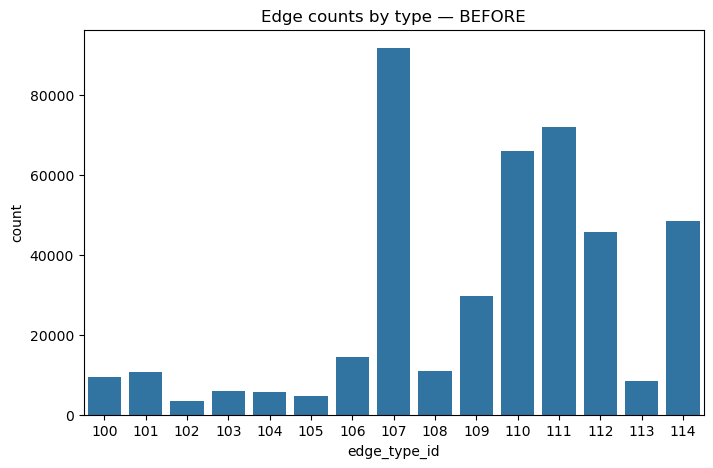

In [4]:

plt.figure(figsize=(8, 5))

# Example 1: Using the 'hue' parameter to color by a column
sns.barplot(
    data=counts_df.to_pandas().head(15),           # Pass the Polars DataFrame directly
    x='edge_type_id',         # Specify the x-axis column name
    y='count',           # Specify the y-axis column name
    #hue='ColorGroup',     # Color the bars based on the 'ColorGroup' column
    #palette='Paired',     # Optional: use a specific color palette
    dodge=False           # Optional: prevents grouping if 'hue' has same categories per x value
)

plt.title('Edge counts by type — BEFORE')
plt.show()

## Step 4 -- Set Parameters for selecting a random fraction of Edges
1. Set the edge type id
2. Set the fraction of edges to retain (randomly sampled from the input)

In [5]:
EDGE_TYPE_TO_REMOVE   =  111
EDGE_FRACTION_TO_RETAIN   = float(0.4)

## Step 5 -- Run the code for editing edges


In [6]:
_etype = EDGE_TYPE_TO_REMOVE
_frac = EDGE_FRACTION_TO_RETAIN
# write output to a temp file so we never modify the source
_out_tmp    = tempfile.NamedTemporaryFile(suffix=".h5", delete=False)
_out_tmp.close()
out_h5_path = Path(_out_tmp.name)

with SonataEdgeEditor(INPUT_H5, edge_type_index_cfg=et_cfg) as _ed:
    _edges = _ed.get_edges_by_type(_etype)
    _n_total = len(_edges)

    # sample a random subset using polars — fraction argument avoids manual n calculation
    _replacement = _edges.sample(fraction=_frac, shuffle=True)

    _ed.replace_edges_by_type(
        edge_type_id=_etype,
        new_edges=_replacement,
        output_path=out_h5_path,
    )

_summary = (
    f"**Edge type `{_etype}`:** original {_n_total} edges → "
    f"replaced with a random subset of **{len(_replacement)}** edges "
    f"({int(_frac * 100)}% of the original set)."
)
print(_summary)

**Edge type `111`:** original 71916 edges → replaced with a random subset of **28766** edges (40% of the original set).


## Step 6 -- Comparing before and after edge population distribution

The reduction in the population of ege type 111 is shown in the plot below

In [7]:
# read type counts from output file
with h5py.File(out_h5_path, "r") as _f:
    _pop_after = list(_f["edges"].keys())[0]
    _etypes_after = _f[f"edges/{_pop_after}/edge_type_id"][:]

counts_after = (
    pl.DataFrame({"edge_type_id": _etypes_after})
    .group_by("edge_type_id")
    .agg(pl.len().alias("count"))
    .sort("edge_type_id")
)


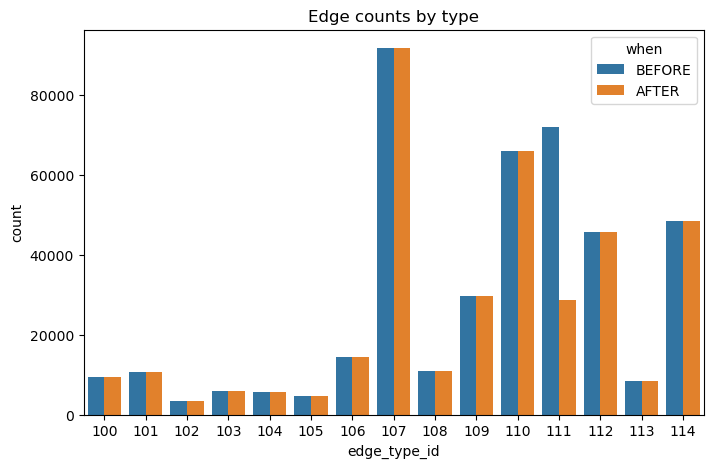

In [8]:

counts_final_df = pl.concat(
    [
        counts_df.head(15).with_columns(pl.lit("BEFORE").alias("when")),
        counts_after.head(15).with_columns(pl.lit("AFTER").alias("when"))
    ]
)

plt.figure(figsize=(8, 5))

# Example 1: Using the 'hue' parameter to color by a column
sns.barplot(
    data=counts_final_df.to_pandas(),           # Pass the Polars DataFrame directly
    x='edge_type_id',         # Specify the x-axis column name
    y='count',           # Specify the y-axis column name
    hue='when',     # Color the bars based on the 'ColorGroup' column
    #palette='Paired',     # Optional: use a specific color palette
    #dodge=False           # Optional: prevents grouping if 'hue' has same categories per x value
)

plt.title('Edge counts by type')
plt.show()
